<a href="https://colab.research.google.com/github/mnuvunm/2026_tues_bigdatacomputing_class/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  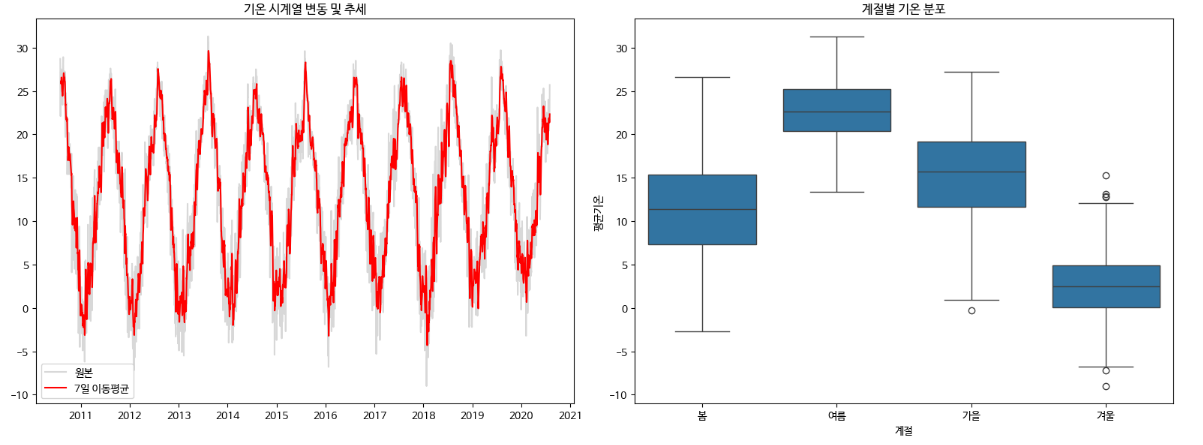

  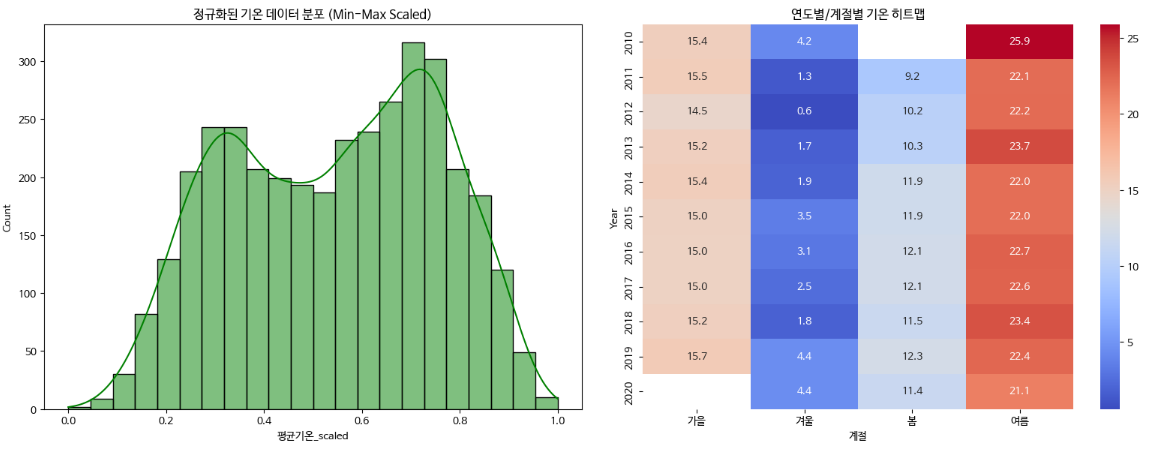



In [114]:
%%writefile setup_korean_font.py
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.font_manager as fm
import pandas as pd

def setup_korean_font():
    """한글 폰트 설정 (수정 버전)"""
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

    # 1. 폰트 파일 존재 여부 확인 및 설치
    if not os.path.exists(font_path):
        print("Installing Nanum fonts...")
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 폰트 추가 (문제의 원인 해결)
    # FontProperties 대신 font_manager.fontManager.addfont를 사용.
    fm.fontManager.addfont(font_path)

    # 3. 전역 설정 적용
    # 'NanumBarunGothic'은 나눔폰트 파일의 실제 이름입니다.
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 한글 폰트 설정 완료 (Matplotlib 연동 성공)")
setup_korean_font()

Overwriting setup_korean_font.py


In [115]:
%run setup_korean_font.py

✅ 한글 폰트 설정 완료 (Matplotlib 연동 성공)


<Figure size 640x480 with 0 Axes>

In [116]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_temp_trend(df):
  df['일시'] = pd.to_datetime(df['일시'])
  df['7일_이동평균'] = df['평균기온'].rolling(window=7).mean()

  plt.plot(df['일시'], df['평균기온'], label='원본', color='#CCCCCC')
  plt.plot(df['일시'], df['7일_이동평균'], label='7일 이동평균', color='red')
  plt.title('기온 시계열 변동 및 추세')
  plt.legend()
  plt.show()

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_seasonal_boxplot(df):
  df['일시'] = pd.to_datetime(df['일시'])
  df['월'] = df['일시'].dt.month

  df['계절'] = '겨울'
  df.loc[(df['월'] >= 3) & (df['월'] <= 5), '계절'] = '봄'
  df.loc[(df['월'] >= 6) & (df['월'] <= 8), '계절'] = '여름'
  df.loc[(df['월'] >= 9) & (df['월'] <= 11), '계절'] = '가을'

  season = ['봄', '여름', '가을', '겨울']
  sns.boxplot(x='계절', y='평균기온', data=df, order=season)
  plt.title('계절별 기온 분포')
  plt.xlabel('계절')
  plt.ylabel('평균기온')
  plt.show()

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_scaled_histogram(df):
  df['평균기온_scaled'] = (df['평균기온'] - df['평균기온'].min()) / (df['평균기온'].max() - df['평균기온'].min())

  sns.histplot(data=df, x='평균기온_scaled', kde=True, color='green')
  plt.title('정규화된 기온 데이터 분포 (Min-Max Scaled)')
  plt.xlabel('평균기온_scaled')
  plt.ylabel('Count')
  plt.show()

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_temp_matrix_heatmap(df):
  df['일시'] = pd.to_datetime(df['일시'])
  df['연도'] = df['일시'].dt.year
  df['월'] = df['일시'].dt.month

  df['계절'] = '겨울'
  df.loc[(df['월'] >= 3) & (df['월'] <= 5), '계절'] = '봄'
  df.loc[(df['월'] >= 6) & (df['월'] <= 8), '계절'] = '여름'
  df.loc[(df['월'] >= 9) & (df['월'] <= 11), '계절'] = '가을'

  pivot_df = df.pivot_table(values='평균기온', index='연도', columns='계절', aggfunc='mean')
  pivot_df = pivot_df[['가을', '겨울', '봄', '여름']] # 작성하신 순서 유지

  plt.figure(figsize=(10, 8))
  sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap='coolwarm')
  plt.title('연도별/계절별 기온 히트맵')
  plt.ylabel('year')
  plt.xlabel('계절')
  plt.show()

In [120]:
def print_yearly_avg_temp(df):
  df['일시'] = pd.to_datetime(df['일시'])
  df['연도'] = df['일시'].dt.year

  yearly_avg = df.groupby('연도')['평균기온'].mean()

  print("연도별 평균기온")
  for year, temp in yearly_avg.items():
    print(f"{year}년 : {temp:.2f}")

In [121]:
def export_to_excel(df):
  filename = 'weather_analysis_report.xlsx'
  print(f"[{filename}] 엑셀 파일 생성을 시작합니다.")

  df['일시'] = pd.to_datetime(df['일시'])
  df['연도'] = df['일시'].dt.year
  df['월'] = df['일시'].dt.month

  df['계절'] = '겨울'
  df.loc[(df['월'] >= 3) & (df['월'] <= 5), '계절'] = '봄'
  df.loc[(df['월'] >= 6) & (df['월'] <= 8), '계절'] = '여름'
  df.loc[(df['월'] >= 9) & (df['월'] <= 11), '계절'] = '가을'

  seasonal_stats = df.groupby('계절')[['평균기온', '최대풍속', '평균풍속']].mean()
  pivot_df = df.pivot_table(values='평균기온', index='연도', columns='계절', aggfunc='mean')[['봄', '여름', '가을', '겨울']]

  with pd.ExcelWriter(filename, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='전처리_데이터', index=False)
    seasonal_stats.to_excel(writer, sheet_name='계절별_통계')
    pivot_df.to_excel(writer, sheet_name='연도별_피벗테이블')

  print("엑셀 파일 내보내기 완료.")

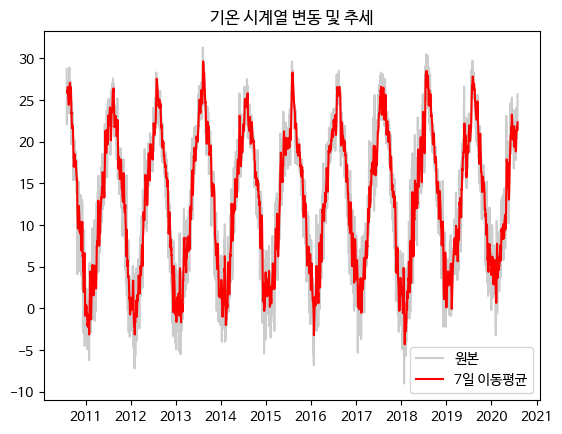

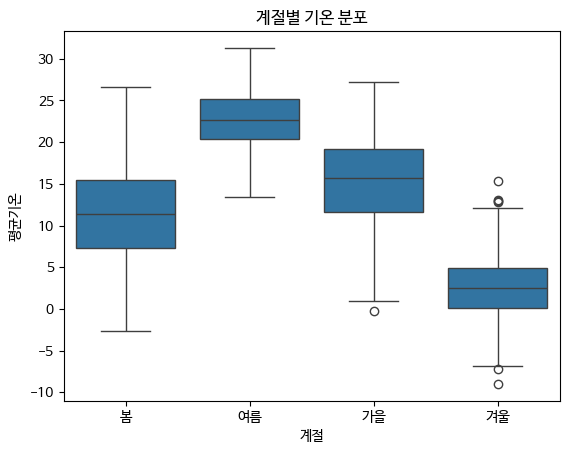

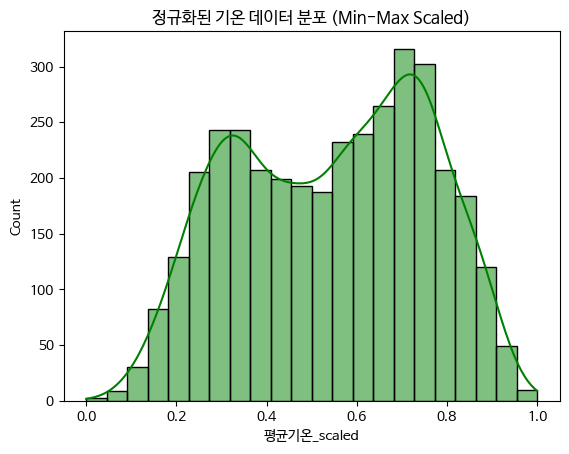

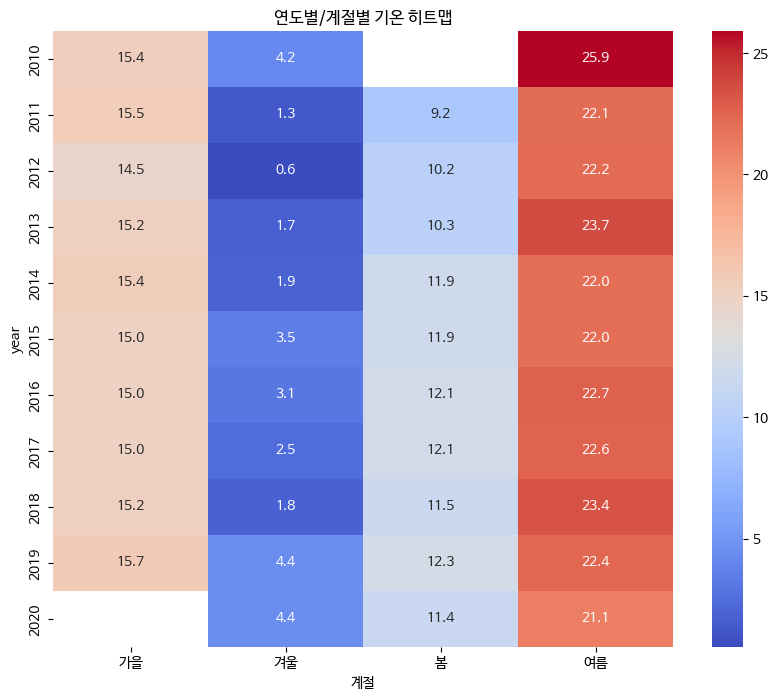

연도별 평균기온
2010년 : 15.24
2011년 : 12.07
2012년 : 11.89
2013년 : 12.80
2014년 : 12.84
2015년 : 13.16
2016년 : 13.24
2017년 : 13.11
2018년 : 13.04
2019년 : 13.77
2020년 : 12.23
[weather_analysis_report.xlsx] 엑셀 파일 생성을 시작합니다.
엑셀 파일 내보내기 완료.


In [122]:
import requests
import io

def main():
  url = 'https://github.com/dongupak/DataML/raw/main/csv/weather.csv'
  response = requests.get(url)
  response.encoding = 'cp949'
  df = pd.read_csv(io.StringIO(response.text))

  plot_temp_trend(df.copy())
  plot_seasonal_boxplot(df.copy())
  plot_scaled_histogram(df.copy())
  plot_temp_matrix_heatmap(df.copy())
  print_yearly_avg_temp(df.copy())
  export_to_excel(df.copy())

main()